In [1]:
!pip install xgboost


In [2]:
!pip install statsmodels


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.tree import plot_tree
from sklearn.metrics import  ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 110)
pd.set_option("display.max_rows", 25970)


In [5]:
# Read an Excel file into a DataFrame using pandas

df = pd.read_excel("/content/drive/MyDrive/UMBCDATA/USM FY 2014 New FT and Transfers Retention Degree and FA  12-21-23 1.xlsx")


In [6]:
# Display the first 5 rows of the DataFrame to get a quick look at the data
df.head()


,campusid,opeid,FirstTimeStatus,Race_New,AttendStatus,Gender,AppZip,EntryMajor,EntryDegree,FY2014Fall,FY2015Fall,FY2016Fall,FY2017Fall,FY2018Fall,FY2019Fall,FY2020Fall,FY2021Fall,FY2022Fall,FY2023Fall,FY2014Spring,FY2015Spring,FY2016Spring,FY2017Spring,FY2018Spring,FY2019Spring,FY2020Spring,FY2021Spring,FY2022Spring,FY2023Spring,FY14FallMajor,FY14SpringMajor,FY15FallMajor,FY15SpringMajor,FY16FallMajor,FY16SpringMajor,FY17FallMajor,FY17SpringMajor,FY18FallMajor,FY18SpringMajor,FY19FallMajor,FY19SpringMajor,FY20FallMajor,FY20SpringMajor,FY21FallMajor,FY21SpringMajor,FY22FallMajor,FY22SpringMajor,FY23FallMajor,FY23SpringMajor,Name,degreedate1,FY1,HegisDeg1,deg1,degreedate2,FY2,hegisdeg2,deg2,degreedate3,FY3,hegisdeg3,deg3,degreedate4,FY4,hegisdeg4,deg4,name2,EFC,EFCAIDFY,CommuteStatus,GrantAmountFY2014,GrantAmountFY2015,GrantAmountFY2016,GrantAmountFY2017,GrantAmountFY2018,GrantAmountFY2019,GrantAmountFY2020,GrantAmountFY2021,GrantAmountFY2022,MeritAmountFY2014,MeritAmountFY2015,MeritAmountFY2016,MeritAmountFY2017,MeritAmountFY2018,MeritAmountFY2019,MeritAmountFY2020,MeritAmountFY2021,MeritAmountFY2022,opeid.1,name,FirstTimeFlag,FirstTimeFlagDesc,Race_NewID,Race_Short,GenderID,GenderShort,AttendStatus.1,Status_Desc,degree,entrydegreeseeking
0,@00147352,210400,5,1,2,2,20705,120300,40,2014.0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120300.0,NaN,120300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",20141223.0,2015.0,120300.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210400,"University of Maryland, Baltimore",5,Undergraduate Transfer-In,1,Black,2,F,2,Part-Time,40,Bachelor's
1,@00159764,210400,5,3,1,2,20876,121300,40,2014.0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121300.0,NaN,121300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",20150515.0,2015.0,121300.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",0.0,2014.0,1.0,NaN,4000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210400,"University of Maryland, Baltimore",5,Undergraduate Transfer-In,3,Asian,2,F,1,Full-Time,40,Bachelor's
2,@00170784,210400,5,9,2,2,21211,120300,40,2014.0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120300.0,NaN,120300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",20150515.0,2015.0,120300.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",14187.0,2014.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210400,"University of Maryland, Baltimore",5,Undergraduate Transfer-In,9,"Muti, Non-Hisp",2,F,2,Part-Time,40,Bachelor's
3,@00186283,210400,5,5,2,2,20852,120300,40,2014.0,2015.0,2016.0,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120300.0,NaN,120300.0,NaN,120300.0,NaN,120300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",20161223.0,2017.0,120300.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210400,"University of Maryland, Baltimore",5,Undergraduate Transfer-In,5,White,2,F,2,Part-Time,40,Bachelor's
4,@00191705,210400,5,5,1,2,20794,120300,40,2014.0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120300.0,NaN,120300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",20150515.0,2015.0,120300.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"University of Maryland, Baltimore",51168.0,2014.0,3.0,3500.0,3500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210400,"University of Maryland, Balt

In [7]:
# Returns (rows, columns) of the DataFrame
df.shape


(30606, 100)

In [8]:
#  Check percentage of missing values in each column
null_percentage = (df.isnull().sum() / len(df)) * 100

# Keep only columns with missing values and sort by percentage
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

# Display the missing data report
print("Columns with missing values (sorted):")
print(null_percentage)


Columns with missing values (sorted):
FY2014Spring         100.000000
deg4                 100.000000
hegisdeg4            100.000000
degreedate4          100.000000
FY4                  100.000000
FY14SpringMajor      100.000000
FY3                   99.973861
deg3                  99.973861
hegisdeg3             99.973861
degreedate3           99.973861
FY2023Spring          99.934653
FY23SpringMajor       99.934653
FY2022Spring          99.885643
FY22SpringMajor       99.885643
FY21SpringMajor       99.846435
FY2021Spring          99.846435
MeritAmountFY2022     99.781089
MeritAmountFY2021     99.735346
GrantAmountFY2022     99.643861
FY20SpringMajor       99.643861
FY2020Spring          99.643861
MeritAmountFY2020     99.637326
GrantAmountFY2021     99.532771
GrantAmountFY2020     99.300791
MeritAmountFY2019     99.274652
FY23FallMajor         99.111285
FY2023Fall            99.111285
FY2022Fall            98.885839
FY22FallMajor         98.885839
FY2019Spring          98.663661
FY

In [9]:
# Fill financial aid columns (assume missing aid = 0)
grant_cols = [col for col in df.columns if 'GrantAmountFY' in col]
merit_cols = [col for col in df.columns if 'MeritAmountFY' in col]
df[grant_cols] = df[grant_cols].fillna(0)
df[merit_cols] = df[merit_cols].fillna(0)


In [10]:
# Columns related to graduation logic
grad_date_cols = [f'degreedate{i}' for i in range(1, 5)]
grad_flag_cols = [f'deg{i}' for i in range(1, 5)]
hegis_cols = ['HegisDeg1'] + [f'hegisdeg{i}' for i in range(2, 5)]
fy_cols = [f'FY{i}' for i in range(1, 5)]

# Fill degree dates with 0 (no graduation date)
df[grad_date_cols] = df[grad_date_cols].fillna(0)

# Fill degree flags and hegis codes with 0 (no degree)
df[grad_flag_cols + hegis_cols + fy_cols] = df[grad_flag_cols + hegis_cols + fy_cols].fillna(0)

# Confirm all nulls handled
print("Remaining nulls in graduation-related columns:")
print(df[grad_date_cols + grad_flag_cols + hegis_cols + fy_cols].isnull().sum())


Remaining nulls in graduation-related columns:
degreedate1    0
degreedate2    0
degreedate3    0
degreedate4    0
deg1           0
deg2           0
deg3           0
deg4           0
HegisDeg1      0
hegisdeg2      0
hegisdeg3      0
hegisdeg4      0
FY1            0
FY2            0
FY3            0
FY4            0
dtype: int64


In [11]:
#  Fill major columns ('0' for no major declared)
major_cols = [col for col in df.columns if 'Major' in col and 'FY' in col]
df[major_cols] = df[major_cols].fillna(0)


In [12]:
#  Fill other demographic fields
for col in ['EFCAIDFY', 'CommuteStatus']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [13]:
# Define list of HEGIS prefixes for STEM majors
stem_prefixes = ('7', '9', '4', '17', '19')

# Function to check if EntryMajor starts with any STEM prefix
df['Stem1'] = df['EntryMajor'].astype(str).apply(
    lambda x: 'Yes' if x.startswith(stem_prefixes) else 'No'
)

# Quick summary
print("STEM Major Distribution:")
print(df['Stem1'].value_counts())


STEM Major Distribution:
Stem1
No     16455
Yes    14151
Name: count, dtype: int64


In [14]:
#  Graduation status
def check_graduation(row):
    for i in range(1, 5):
        if pd.notnull(row[f'degreedate{i}']) and row[f'degreedate{i}'] != 0:
            return 'Yes'
    return 'No'
df['Graduated'] = df.apply(check_graduation, axis=1)

In [15]:
#  Total support and flags
df['totalsupport'] = df[grant_cols + merit_cols].sum(axis=1)
df['supportedY1'] = df.apply(lambda x: 1 if (x['GrantAmountFY2014'] + x['MeritAmountFY2014']) > 0 else 0, axis=1)
df['supported'] = df['totalsupport'].apply(lambda x: 1 if x > 0 else 0)


In [16]:
#  Categorize EFC
def categorize_efc(val):
    if val == -1:
        return 'Unknown'
    elif val < 6657:
        return 'High'
    elif 6657 <= val <= 13312:
        return 'Medium'
    else:
        return 'Low'
df['EFC_Category'] = df['EFC'].apply(categorize_efc)

In [17]:
#  Determine "In Need" status
need_cols = [col for col in df.columns if 'Need' in col and 'FY' in col]
need_values = ['High', 'Medium', 'Low']
df['In_Need'] = df[need_cols].apply(lambda row: 'Yes' if any(val in need_values for val in row.values) else 'No', axis=1)


In [18]:
#  Full-time enrollment flag
sem_cols = [col for col in df.columns if col.startswith('FY') and ('Fall' in col or 'Spring' in col)]
df['Is_FullTime'] = df[sem_cols].apply(lambda row: 'Yes' if 'FT' in row.values else 'No', axis=1)

In [19]:
# Function to get the first declared major (ignoring nulls and 0s)
def get_first_major(row):
    majors = [m for m in row if pd.notnull(m) and m != 0]
    return majors[0] if majors else None  # Return first valid major

# Function to get the last declared major (ignoring nulls and 0s)
def get_last_major(row):
    majors = [m for m in row if pd.notnull(m) and m != 0]
    return majors[-1] if majors else None  # Return last valid major

# Check if the student switched majors in the middle but ended on the same major
def changed_in_middle(row):
    majors = [m for m in row if pd.notnull(m) and m != 0]
    return 'Yes' if len(set(majors)) > 1 and majors[0] == majors[-1] else 'No'

# Count the number of times a student switched majors
def count_major_switches(row):
    majors = [m for m in row if pd.notnull(m) and m != 0]
    return sum(majors[i] != majors[i+1] for i in range(len(majors)-1))

# Apply the above functions to compute major change-related features
df['Initial_Major'] = df[major_cols].apply(get_first_major, axis=1)  # First valid major
df['Final_Major'] = df[major_cols].apply(get_last_major, axis=1)     # Last valid major

# Binary column: Did the student change their major from start to end?
df['Changed_Major'] = df.apply(
    lambda x: 'Yes' if x['Initial_Major'] and x['Final_Major'] and x['Initial_Major'] != x['Final_Major'] else 'No',
    axis=1
)

# Did the student change majors in the middle but start and end with the same one?
df['Changed_In_Middle'] = df[major_cols].apply(changed_in_middle, axis=1)

# Total number of unique majors over the years
df['Num_Majors'] = df[major_cols].apply(
    lambda row: len(set([m for m in row if pd.notnull(m) and m != 0])),
    axis=1
)

# Number of times the student changed majors (based on year-to-year differences)
df['Major_Change_Count'] = df[major_cols].apply(count_major_switches, axis=1)


In [20]:
# Got_Grant: Mark 'Yes' if the student received any grant amount in any year; otherwise 'No'
df['Got_Grant'] = df[grant_cols].sum(axis=1).apply(lambda x: 'Yes' if x > 0 else 'No')

# Got_Merit: Mark 'Yes' if the student received any merit scholarship in any year; otherwise 'No'
df['Got_Merit'] = df[merit_cols].sum(axis=1).apply(lambda x: 'Yes' if x > 0 else 'No')


In [21]:
# Preview result
df[['Graduated', 'Initial_Major', 'Final_Major', 'Changed_Major', 'Got_Grant', 'Got_Merit', 'supportedY1', 'In_Need', 'Is_FullTime','totalsupport']].head()


,Graduated,Initial_Major,Final_Major,Changed_Major,Got_Grant,Got_Merit,supportedY1,In_Need,Is_FullTime,totalsupport
0,Yes,120300.0,120300.0,No,No,No,0,No,No,0.0
1,Yes,121300.0,121300.0,No,Yes,Yes,1,No,No,6000.0
2,Yes,120300.0,120300.0,No,No,No,0,No,No,0.0
3,Yes,120300.0,120300.0,No,No,No,0,No,No,0.0
4,Yes,120300.0,120300.0,No,Yes,No,1,No,No,7000.0


In [22]:
# Select features and target
target = 'Graduated'
features = ['totalsupport', 'supportedY1', 'supported', 'EFC_Category', 'In_Need', 'Is_FullTime', 'Changed_Major', 'Changed_In_Middle', 'Got_Grant', 'Got_Merit']
X = df[features]
y = df[target].map({'Yes': 1, 'No': 0})


In [23]:
# Handle categorical variables
cat_cols = ['EFC_Category', 'In_Need', 'Is_FullTime', 'Changed_Major', 'Changed_In_Middle', 'Got_Grant', 'Got_Merit']
num_cols = ['totalsupport', 'supportedY1', 'supported']

In [24]:
# Raw pipeline
raw_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

raw_tree = Pipeline([
    ('preprocessor', raw_preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
raw_tree.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['EFC_Category', 'In_Need',
                                                   'Is_FullTime',
                                                   'Changed_Major',
                                                   'Changed_In_Middle',
                                                   'Got_Grant',
                                                   'Got_Merit'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score


[Raw] Accuracy: 0.7342371773930089
[Raw] Precision: 0.7666853617498598
[Raw] Recall: 0.7747237177670728
[Raw] F1 Score: 0.7706835799859055
[Raw] ROC AUC: 0.7269299267585847


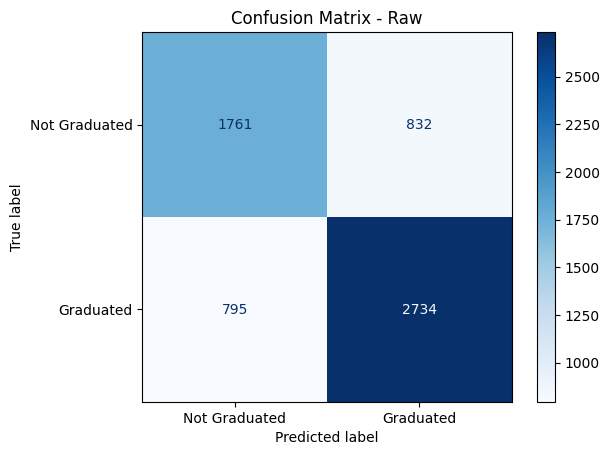

In [26]:
# Raw performance
y_pred_raw = raw_tree.predict(X_test)
print("[Raw] Accuracy:", accuracy_score(y_test, y_pred_raw))
print("[Raw] Precision:", precision_score(y_test, y_pred_raw))
print("[Raw] Recall:", recall_score(y_test, y_pred_raw))
print("[Raw] F1 Score:", f1_score(y_test, y_pred_raw))
print("[Raw] ROC AUC:", roc_auc_score(y_test, y_pred_raw))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_raw, display_labels=['Not Graduated', 'Graduated'], cmap='Blues')
plt.title("Confusion Matrix - Raw")
plt.show()

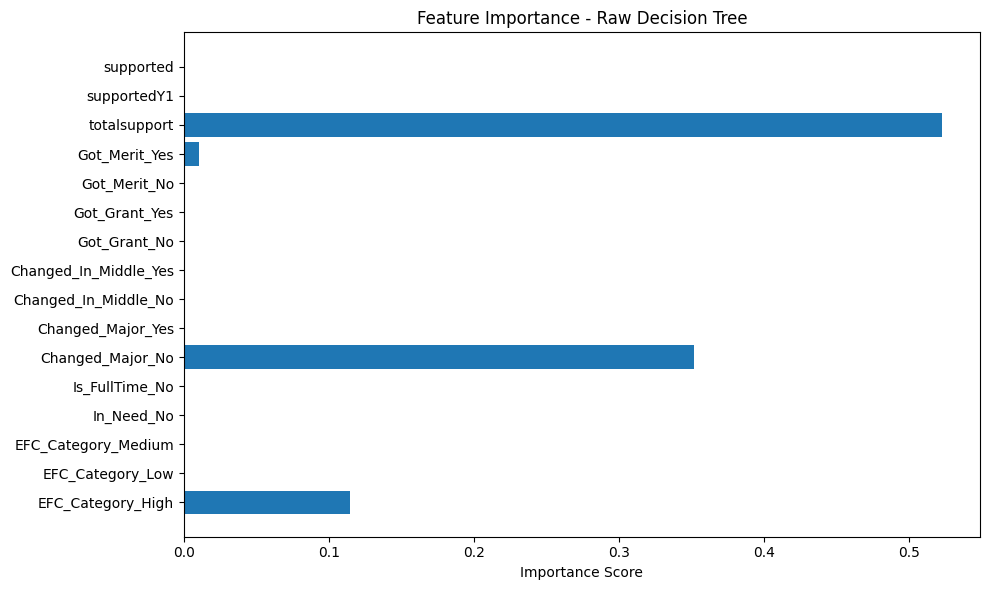

In [27]:
# Extract cleaned feature names
feature_names_raw = [
    name.split('__')[-1] for name in raw_tree.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_raw = raw_tree.named_steps['classifier'].feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names_raw, importances_raw)
plt.xlabel("Importance Score")
plt.title("Feature Importance - Raw Decision Tree")
plt.tight_layout()
plt.show()


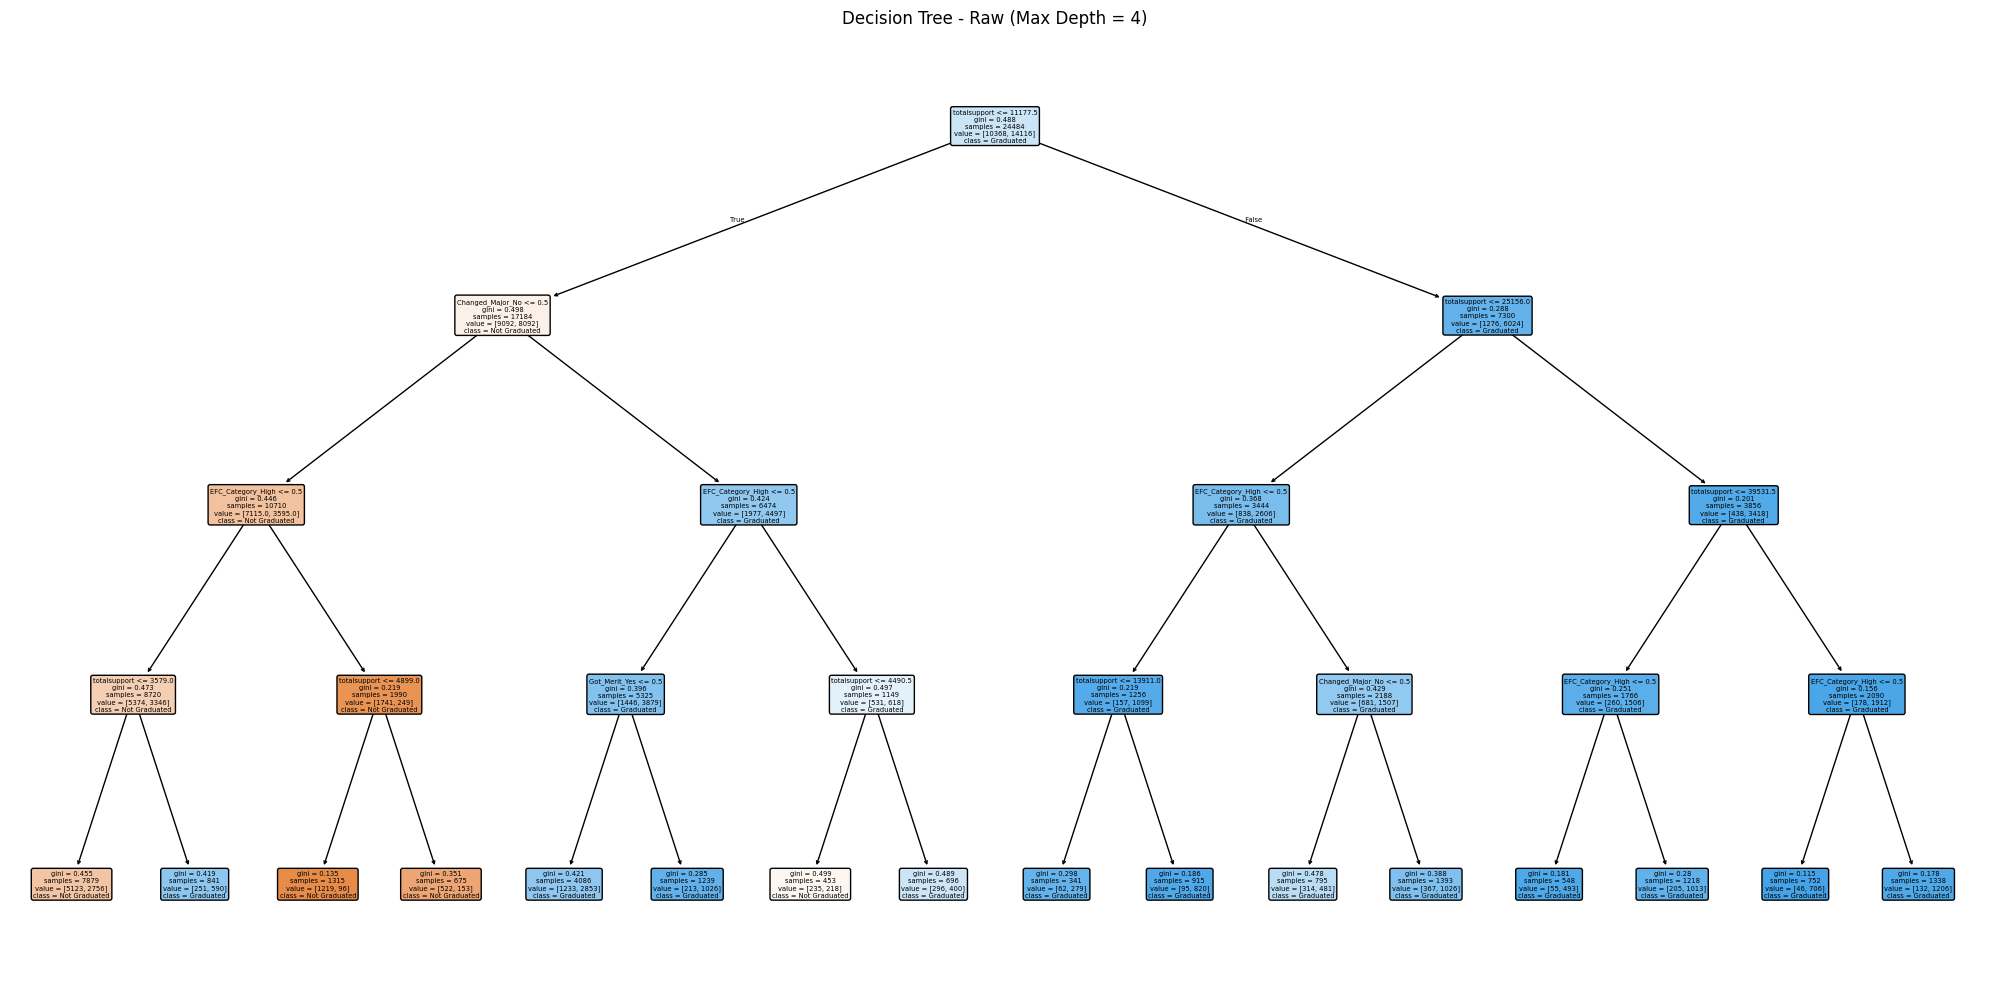

In [28]:
# Extract clean feature names from the raw pipeline
feature_names_raw = [
    name.split('__')[-1] for name in raw_tree.named_steps['preprocessor'].get_feature_names_out()
]

# Plot and save the decision tree for the raw pipeline
plt.figure(figsize=(20, 10))
plot_tree(
    raw_tree.named_steps['classifier'],
    feature_names=feature_names_raw,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree - Raw (Max Depth = 4)")
plt.tight_layout()
plt.savefig("decision_tree_raw.png", dpi=1000)
plt.show()


In [29]:
# Scaled pipeline
scaled_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

scaled_tree = Pipeline([
    ('preprocessor', scaled_preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

scaled_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['totalsupport',
                                                   'supportedY1',
                                                   'supported']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EFC_Category', 'In_Need',
                                                   'Is_FullTime',
                                                   'Changed_Major',
                                                   'Changed_In_Middle',
                                                   'Got_Grant',
                                                   'Got_Merit'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

[Scaled] Accuracy: 0.7342371773930089
[Scaled] Precision: 0.7666853617498598
[Scaled] Recall: 0.7747237177670728
[Scaled] F1 Score: 0.7706835799859055
[Scaled] ROC AUC: 0.7269299267585847


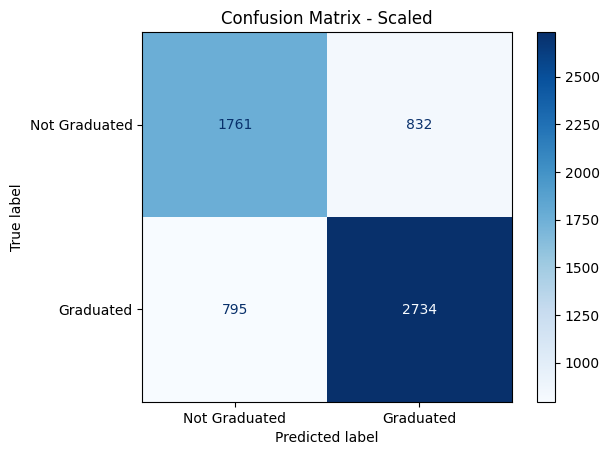

In [30]:
# Scaled performance
y_pred_scaled = scaled_tree.predict(X_test)
print("[Scaled] Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("[Scaled] Precision:", precision_score(y_test, y_pred_scaled))
print("[Scaled] Recall:", recall_score(y_test, y_pred_scaled))
print("[Scaled] F1 Score:", f1_score(y_test, y_pred_scaled))
print("[Scaled] ROC AUC:", roc_auc_score(y_test, y_pred_scaled))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled, display_labels=['Not Graduated', 'Graduated'], cmap='Blues')
plt.title("Confusion Matrix - Scaled")
plt.show()

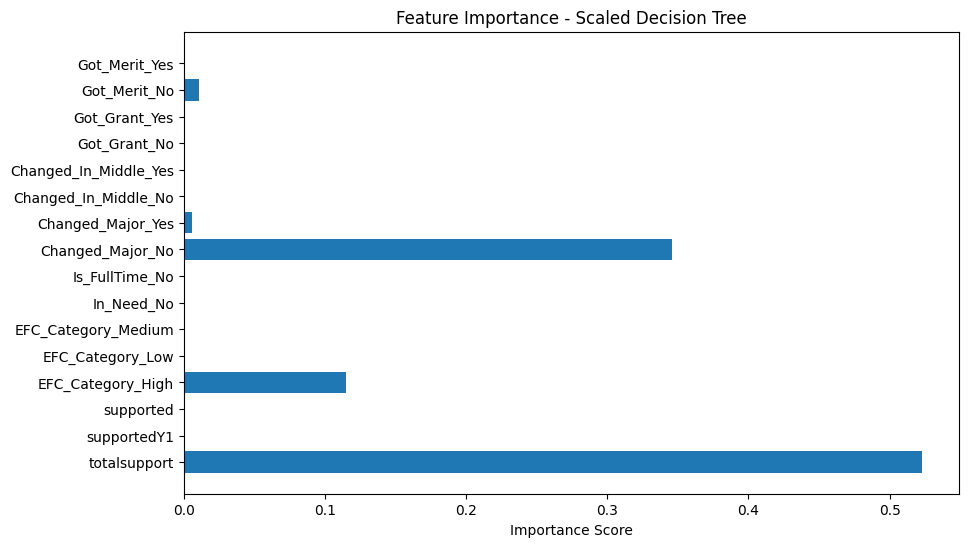

In [31]:
# Extract cleaned feature names for scaled tree
feature_names_scaled = [
    name.split('__')[-1] for name in scaled_tree.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_scaled = scaled_tree.named_steps['classifier'].feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names_scaled, importances_scaled)
plt.xlabel("Importance Score")
plt.title("Feature Importance - Scaled Decision Tree")
plt.show()


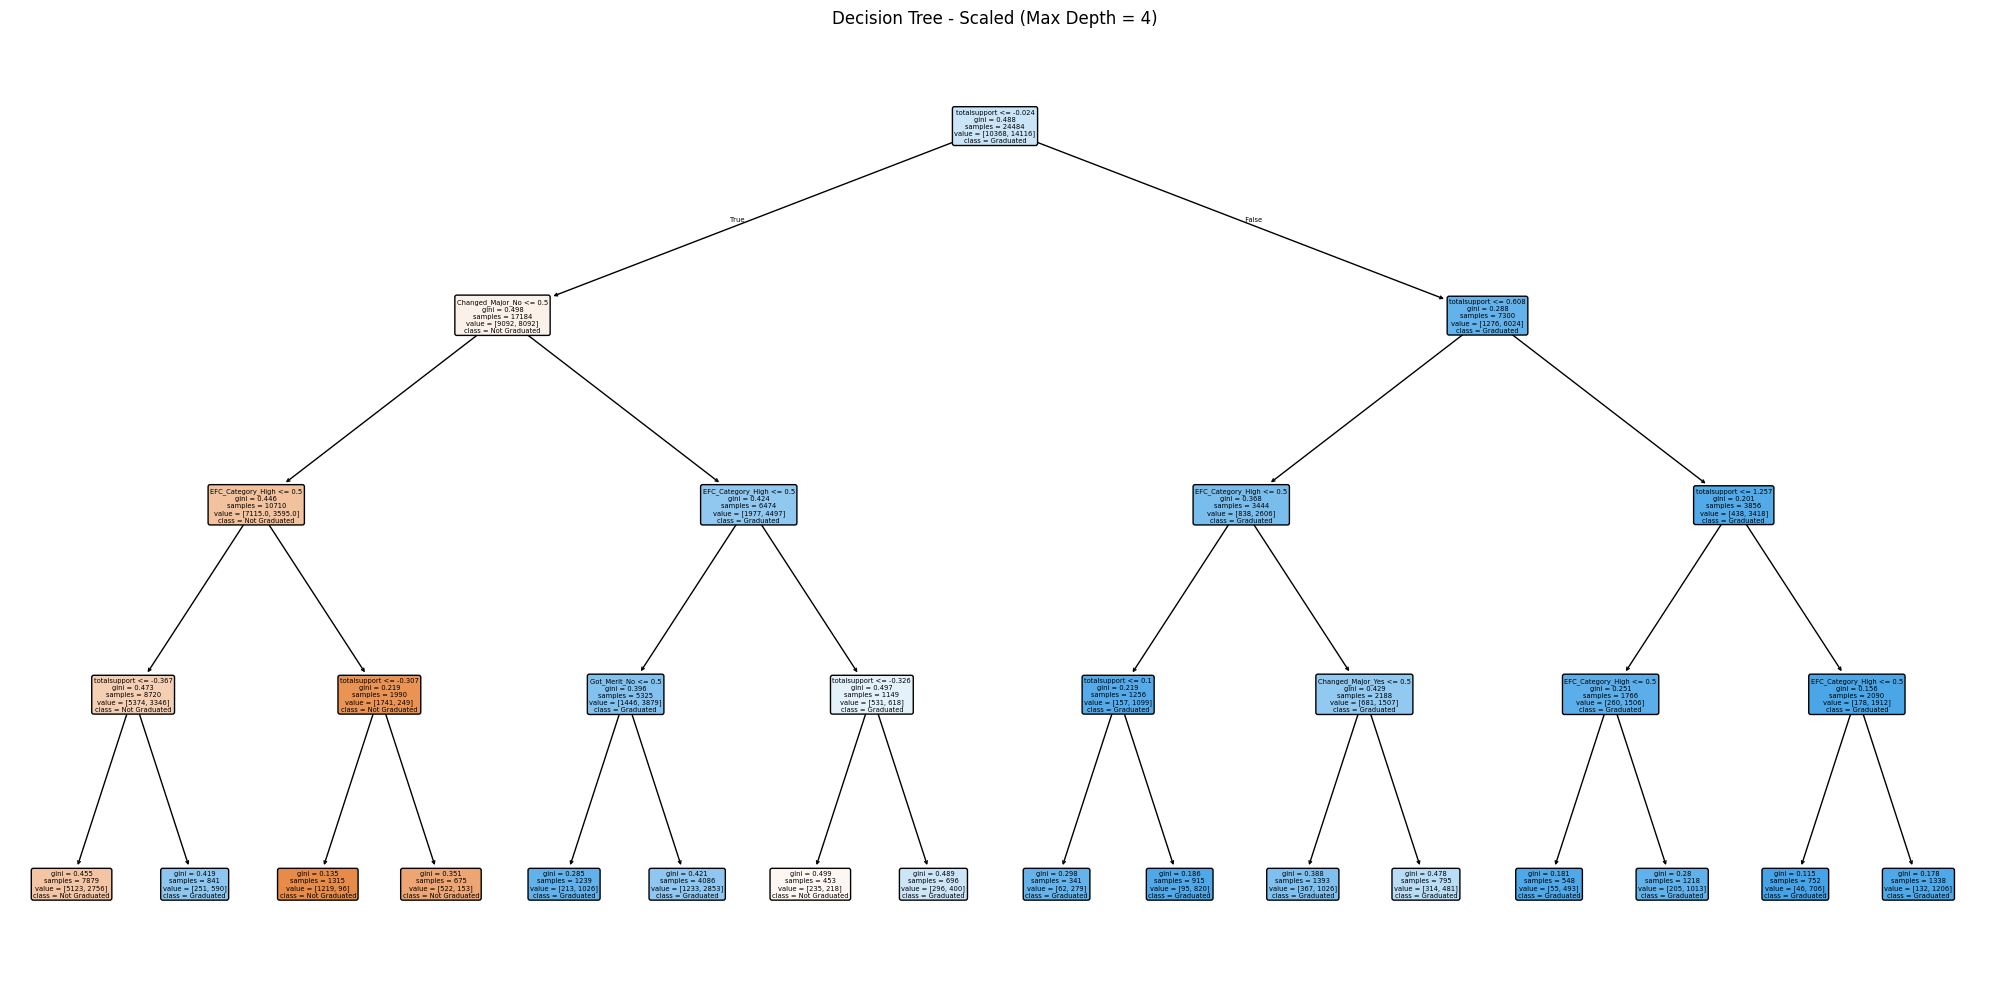

In [32]:
# Extract cleaned feature names for the scaled tree
feature_names_scaled = [
    name.split('__')[-1] for name in scaled_tree.named_steps['preprocessor'].get_feature_names_out()
]

# Plot and save the decision tree for the scaled pipeline
plt.figure(figsize=(20, 10))
plot_tree(
    scaled_tree.named_steps['classifier'],
    feature_names=feature_names_scaled,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree - Scaled (Max Depth = 4)")
plt.tight_layout()
plt.savefig("decision_tree_scaled.png", dpi=1000)
plt.show()


In [33]:
from sklearn.tree import export_text

# ---- RAW Tree: Human-readable format ----
print("\n[Human Readable Decision Tree - RAW]:\n")
tree_raw_model = raw_tree.named_steps['classifier']
tree_text_raw = export_text(tree_raw_model, feature_names=feature_names_raw)
print(tree_text_raw)

# ---- SCALED Tree: Human-readable format ----
print("\n[Human Readable Decision Tree - SCALED]:\n")
tree_scaled_model = scaled_tree.named_steps['classifier']
tree_text_scaled = export_text(tree_scaled_model, feature_names=feature_names_scaled)
print(tree_text_scaled)



[Human Readable Decision Tree - RAW]:

|--- totalsupport <= 11177.50
|   |--- Changed_Major_No <= 0.50
|   |   |--- EFC_Category_High <= 0.50
|   |   |   |--- totalsupport <= 3579.00
|   |   |   |   |--- class: 0
|   |   |   |--- totalsupport >  3579.00
|   |   |   |   |--- class: 1
|   |   |--- EFC_Category_High >  0.50
|   |   |   |--- totalsupport <= 4899.00
|   |   |   |   |--- class: 0
|   |   |   |--- totalsupport >  4899.00
|   |   |   |   |--- class: 0
|   |--- Changed_Major_No >  0.50
|   |   |--- EFC_Category_High <= 0.50
|   |   |   |--- Got_Merit_Yes <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Got_Merit_Yes >  0.50
|   |   |   |   |--- class: 1
|   |   |--- EFC_Category_High >  0.50
|   |   |   |--- totalsupport <= 4490.50
|   |   |   |   |--- class: 0
|   |   |   |--- totalsupport >  4490.50
|   |   |   |   |--- class: 1
|--- totalsupport >  11177.50
|   |--- totalsupport <= 25156.00
|   |   |--- EFC_Category_High <= 0.50
|   |   |   |--- totalsupport <= 13911.